In [1]:
# 1. Install dan Import
!pip install datasets transformers scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 6.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
# 2. Load Dataset
dataset = load_dataset("wmt14", "de-en")
train_data = dataset["train"].select(range(5000))  # Subset for faster training
test_data = dataset["test"].select(range(1000))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/273M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/474k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/509k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4508785 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

In [6]:
# Cek satu contoh data
print(train_data[0])

{'translation': {'de': 'Wiederaufnahme der Sitzungsperiode', 'en': 'Resumption of the session'}}


In [12]:
from transformers import T5Tokenizer
from torch.utils.data import Dataset

# Load T5 tokenizer
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Fungsi tokenisasi
def tokenize(pair):
    input_text = "translate German to English: " + pair['translation']['de']
    target_text = pair['translation']['en']
    input_tokens = tokenizer(input_text, padding="max_length", truncation=True, max_length=64, return_tensors="pt")
    target_tokens = tokenizer(target_text, padding="max_length", truncation=True, max_length=64, return_tensors="pt")
    return input_tokens.input_ids.squeeze(), target_tokens.input_ids.squeeze()

# Dataset custom
class TranslationDataset(Dataset):
    def __init__(self, data):
        self.pairs = [tokenize(pair) for pair in data]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

train_dataset = TranslationDataset(train_data)
test_dataset = TranslationDataset(test_data)


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [13]:
# 4. Model LSTM Encoder-Decoder
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, hidden, cell):
        embedded = self.embedding(tgt)
        outputs, _ = self.lstm(embedded, (hidden, cell))
        predictions = self.fc(outputs)
        return predictions

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        hidden, cell = self.encoder(src)
        output = self.decoder(tgt, hidden, cell)
        return output

vocab_size = tokenizer.vocab_size
model = Seq2Seq(
    Encoder(vocab_size, 256, 512),
    Decoder(vocab_size, 256, 512)
).to("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
# 5. Training
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train(model, loader):
    model.train()
    total_loss = 0
    for src, tgt in tqdm(loader):
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt[:, :-1])
        loss = criterion(output.view(-1, vocab_size), tgt[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt[:, :-1])
            preds = torch.argmax(output, dim=-1)
            for i in range(preds.shape[0]):
                pred_flat = preds[i].cpu().numpy()
                tgt_flat = tgt[i, 1:].cpu().numpy()
                mask = tgt_flat != tokenizer.pad_token_id
                predictions.extend(pred_flat[mask])
                actuals.extend(tgt_flat[mask])
    return actuals, predictions


In [17]:
# 6. Loop Train dan Evaluasi
for epoch in range(1, 11):
    train_loss = train(model, train_loader)
    print(f"Epoch {epoch} Loss: {train_loss:.4f}")

# Evaluasi
y_true, y_pred = evaluate(model, test_loader)


100%|██████████| 157/157 [00:13<00:00, 11.75it/s]


Epoch 1 Loss: 6.1999


100%|██████████| 157/157 [00:12<00:00, 12.27it/s]


Epoch 2 Loss: 5.1139


100%|██████████| 157/157 [00:13<00:00, 12.02it/s]


...

Epoch 8 Loss: 3.5336


100%|██████████| 157/157 [00:13<00:00, 11.61it/s]


Epoch 9 Loss: 3.3700


100%|██████████| 157/157 [00:13<00:00, 11.66it/s]


Epoch 10 Loss: 3.2096


In [18]:
# 7. Evaluasi Metrik
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

# Untuk AUC dan ROC, harus binary, jadi kita ambil satu label (contoh: token <eos>)
eos_token = tokenizer.eos_token_id
y_true_bin = [1 if y == eos_token else 0 for y in y_true]
y_pred_bin = [1 if y == eos_token else 0 for y in y_pred]

auc = roc_auc_score(y_true_bin, y_pred_bin)
fpr, tpr, _ = roc_curve(y_true_bin, y_pred_bin)

print(f"Akurasi  : {accuracy:.4f}")
print(f"Presisi  : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")


Akurasi  : 0.1671
Presisi  : 0.0081
Recall   : 0.0080
F1 Score : 0.0065
AUC      : 0.9592


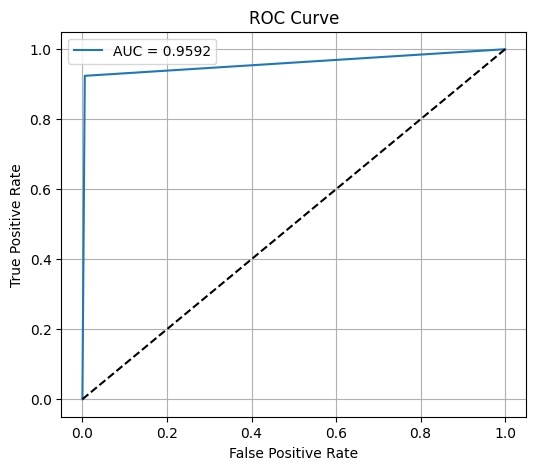

In [20]:
# 8. Visualisasi ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()